# Chicago flood maps: FEMA vs First Street

Rebuilds the chart from the LinkedIn post *Climate risk is priced at the search*, starting from the Chicago Fed article.

## Step 0. Set up

You need Python 3 with `requests`, `pypdf`, `pandas` and `matplotlib`
(`pip install requests pypdf pandas matplotlib`). Run the cells from top to bottom.
Downloaded documents go in `sources/`; the finished chart goes in `output/`.

In [1]:
# Chart style used on every chart: Google Sans if installed, white background, quiet grid,
# vertical columns, both axes drawn, sources printed with links in [brackets].
import logging
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
for font_file in Path.home().glob("Library/Fonts/GoogleSans-*.ttf"):
    font_manager.fontManager.addfont(str(font_file))
plt.rcParams.update({
    "font.family": ["Google Sans", "Arial", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#14213D",
    "axes.linewidth": 1.2,
    "axes.labelcolor": "#4F5B6E",
    "xtick.color": "#14213D",
    "ytick.color": "#4F5B6E",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E3E6EB",
    "figure.facecolor": "white",
})
BLUE, GREY, INK, MUTED = "#1F56A8", "#8A94A6", "#14213D", "#4F5B6E"

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)


def frame_chart(fig, title, subtitle, sources, credit="Chart: Amy Chen"):
    """Title = the one takeaway; subtitle = what is plotted; footer = every source with its link."""
    fig.text(0.06, 0.94, title, fontsize=21, fontweight="bold", color=INK, va="top", wrap=True)
    fig.text(0.06, 0.865, subtitle, fontsize=13, color=MUTED, va="top")
    y = 0.075 + 0.032 * (len(sources) - 1)
    for label, url in sources:
        fig.text(0.06, y, f"Source: {label} [{url}]", fontsize=8.5, color=MUTED)
        y -= 0.032
    fig.text(0.94, 0.03, credit, fontsize=9, color=MUTED, ha="right")

In [2]:
# Download a file once and keep it in ./sources, so every later step reads the same copy.
import requests

SOURCES = Path("sources")
SOURCES.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "Mozilla/5.0 (research notebook; reproducing a published chart)"}


def download(url, filename):
    path = SOURCES / filename
    if not path.exists():
        response = requests.get(url, headers=HEADERS, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    print(f"{filename}: {path.stat().st_size:,} bytes")
    return path

## Step 1. Download the Chicago Fed article (2020)

The Federal Reserve Bank of Chicago compared FEMA's flood maps with First Street Foundation's model,
which also counts heavy rain (pluvial flooding).

In [3]:
import html, re

page = download("https://www.chicagofed.org/publications/blogs/chicago-fed-insights/2020/chicago-flood-risk", "chicago-fed-flood-risk-2020.html")
text = html.unescape(re.sub(r"<[^>]+>", " ", page.read_text(encoding="utf-8")))
text = " ".join(text.split())   # plain text, single spaces

chicago-fed-flood-risk-2020.html: 102,222 bytes


## Step 2. Find the sentence with both numbers

In [4]:
at = text.find("FEMA flood maps place 0.3% of Chicago properties")
assert at >= 0, "sentence not found: the article may have changed"
sentence = text[at: at + 330]
print(sentence)

FEMA flood maps place 0.3% of Chicago properties in a once-in-100 year flood zone, but an alternative measure from First Street Foundation (FSF) estimates that 12.8% of Chicago’s 600,000+ properties may be at risk during a once-in-100 year flood, a difference of 75,623 properties. 3 So what explains this difference? Well, FSF’s 


In [5]:
fema_share = float(re.search(r"place ([\d.]+)% of Chicago properties", sentence).group(1))
first_street_share = float(re.search(r"estimates that ([\d.]+)% of Chicago", sentence).group(1))
print(f"FEMA {fema_share}%  |  First Street {first_street_share}%  |  ratio {first_street_share / fema_share:.0f}x")
assert (fema_share, first_street_share) == (0.3, 12.8)

FEMA 0.3%  |  First Street 12.8%  |  ratio 43x


## Step 3. A supporting fact from the same article

Most flood damage happens outside the mapped floodplain. Printed here so it can be quoted with its source.

In [6]:
at = text.find("90 percent of flood damage claims")
print(text[at - 40: at + 160])

ood damage. 4 The IDNR study found that 90 percent of flood damage claims between 2007 and 2014 were for properties located outside of the mapped 100‐year floodplain. The overwhelming majority of floo


## Step 4. Draw the chart

Two columns, values on the y-axis. The headline states the ratio (12.8 / 0.3 ≈ 43, written as "40 times").

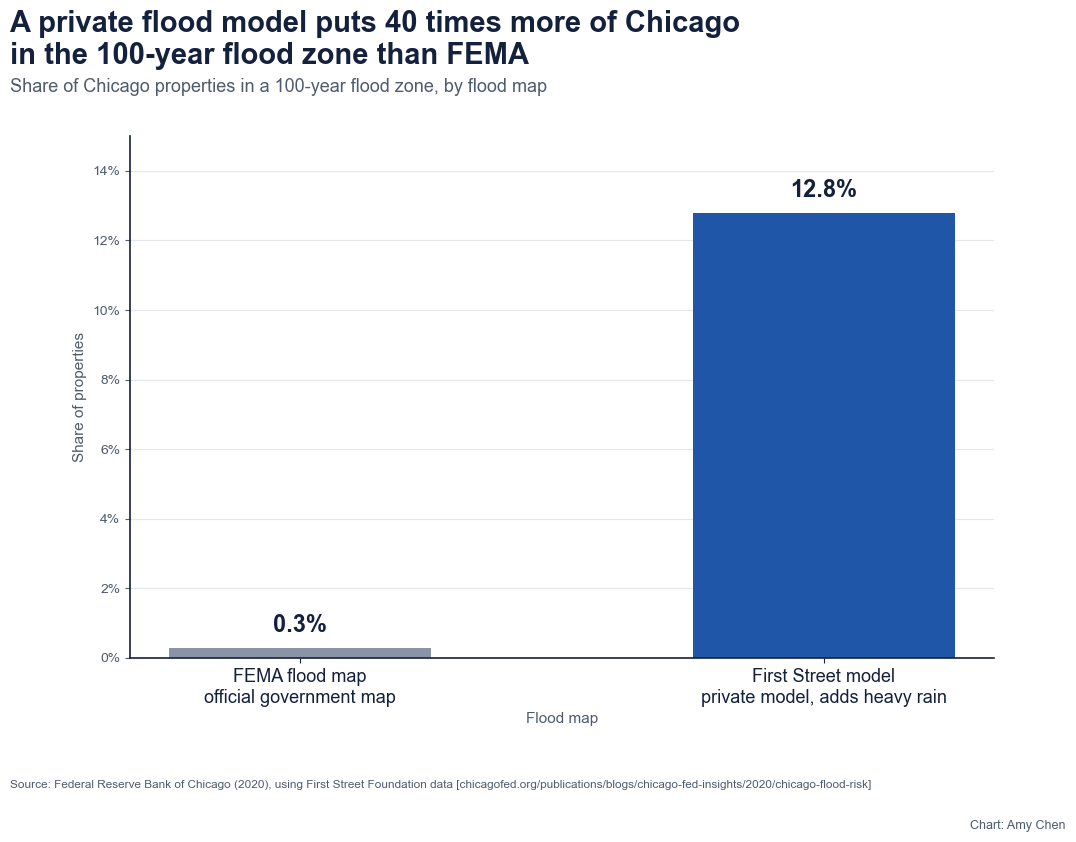

In [7]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_axes([0.16, 0.22, 0.72, 0.58])
labels = ["FEMA flood map\nofficial government map", "First Street model\nprivate model, adds heavy rain"]
values = [fema_share, first_street_share]
ax.bar([0, 1], values, width=0.5, color=[GREY, BLUE])
for i, v in enumerate(values):
    ax.text(i, v + 0.3, f"{v}%", ha="center", va="bottom", fontsize=17, fontweight="bold", color=INK)
ax.set_xticks([0, 1], labels, fontsize=13)
ax.set_xlabel("Flood map", fontsize=11)
ax.set_ylabel("Share of properties", fontsize=11)
ax.set_ylim(0, 15)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_axisbelow(True)
frame_chart(
    fig,
    "A private flood model puts 40 times more of Chicago\nin the 100-year flood zone than FEMA",
    "Share of Chicago properties in a 100-year flood zone, by flood map",
    [("Federal Reserve Bank of Chicago (2020), using First Street Foundation data",
      "chicagofed.org/publications/blogs/chicago-fed-insights/2020/chicago-flood-risk")],
)
fig.savefig(OUTPUT / "chicago_fema_vs_first_street.png", dpi=200)
plt.show()